# Consumer Application and Data Persistence

Santiago Elí Jiménez Aguilar  
Luis Eduardo Gonzalez Gloria

## Consumer Application

This section is the core of the project and carries the highest weight. <br>
Teams must implement a PySpark Structured Streaming pipeline that demonstrates mastery of the use of the PySpark API to manage data frames that increase their content continuously.<br>
Evaluation criteria: correctness of the streaming API usage and complexity of transformations.

## Data Persistence

Persist streaming results as documents in a MongoDB collection using the mongo-spark-connector.<br>
Teams must define the collection schema, configure the write concern, and use foreachBatch to upsert records.<br>
Include at least one aggregation pipeline query that reads the persisted data to validate the sink.

The deliverable must include a screenshot of the database UI or a query result confirming that records were successfully persisted.<br>
Evaluation criteria: correct connector usage, schema definition, credential management, and evidence of successful persistence.

## Instructions
- **Recieve Events**. Read stream to Kafka.
- **Enrich Stream**. Parse, Cast and Enrich Stream.
- **Writing Data in MongoDB**. This section should contain code to persist the enriched dataset in MongoDB.
- **Inspect MongoDB Collections**. This section should contain a screenshot of documents obtained by inspecting the collection in the MongoDB container.

In [1]:
from spark_utils import SparkUtils
from pathlib import Path
import shutil
import pyspark.sql.functions as F
from pyspark.sql.types import (
    StructType, StringType, DoubleType, IntegerType, BooleanType
)

mongodb_connector = "org.mongodb.spark:mongo-spark-connector_2.13:10.5.0"
kafka_connector = "org.apache.spark:spark-sql-kafka-0-10_2.13:4.0.0"
su = SparkUtils("FinalProject_kafka_mongodb",
                "spark://spark-master:7077",
                spark_packages=f"{kafka_connector},{mongodb_connector}")
su.spark

:: loading settings :: url = jar:file:/opt/spark/jars/ivy-2.5.3.jar!/org/apache/ivy/core/settings/ivysettings.xml
Ivy Default Cache set to: /root/.ivy2.5.2/cache
The jars for the packages stored in: /root/.ivy2.5.2/jars
org.apache.spark#spark-sql-kafka-0-10_2.13 added as a dependency
org.mongodb.spark#mongo-spark-connector_2.13 added as a dependency
:: resolving dependencies :: org.apache.spark#spark-submit-parent-dc0a3201-7c0c-4c92-873b-829cd4e11f29;1.0
	confs: [default]
	found org.apache.spark#spark-sql-kafka-0-10_2.13;4.0.0 in central
	found org.apache.spark#spark-token-provider-kafka-0-10_2.13;4.0.0 in central
	found org.apache.kafka#kafka-clients;3.9.0 in central
	found org.lz4#lz4-java;1.8.0 in central
	found org.xerial.snappy#snappy-java;1.1.10.7 in central
	found org.slf4j#slf4j-api;2.0.16 in central
	found org.apache.hadoop#hadoop-client-runtime;3.4.1 in central
	found org.apache.hadoop#hadoop-client-api;3.4.1 in central
	found com.google.code.findbugs#jsr305;3.0.0 in central


### DataFrame

In [2]:
USERS_PATH   = "/opt/spark/work-dir/data/users/users.csv"
CONTENT_PATH = "/opt/spark/work-dir/data/content/content.csv"

users_df = (
    su.spark.read
    .option("header", True)
    .option("inferSchema", True)
    .csv(USERS_PATH)
    .select("user_id", "username", "country", "subscription_type", "preferred_device")
)

content_df = (
    su.spark.read
    .option("header", True)
    .option("inferSchema", True)
    .csv(CONTENT_PATH)
    .select("content_id", "title", "genre", "content_type", "language", "studio")
)

users_df.cache()
content_df.cache()

print(f"Users loaded    : {users_df.count()} records")
print(f"Content loaded  : {content_df.count()} records")
users_df.show(5, truncate=False)
content_df.show(5, truncate=False)

Users loaded    : 100 records
Content loaded  : 100 records
+--------+---------------+----------+-----------------+----------------+
|user_id |username       |country   |subscription_type|preferred_device|
+--------+---------------+----------+-----------------+----------------+
|U0000001|johnsonjoshua  |Spain     |free             |laptop          |
|U0000002|robinsonwilliam|Chile     |basic            |smart_tv        |
|U0000003|lisa02         |Costa Rica|premium          |smart_tv        |
|U0000004|howardmaurice  |Colombia  |basic            |mobile          |
|U0000005|barbara10      |Nicaragua |basic            |Wii             |
+--------+---------------+----------+-----------------+----------------+
only showing top 5 rows
+----------+--------------------------------------------+-----------+------------+--------+---------------------+
|content_id|title                                       |genre      |content_type|language|studio               |
+----------+-------------------

### Watch event

Each Kafka message is a JSON object produced by `producer_streaming.ipynb`.  
The schema matches the columns generated by `generate_data.pyw`.

In [3]:
watch_schema = (
    StructType()
    .add("event_id",             StringType())
    .add("user_id",              StringType())
    .add("content_id",           StringType())
    .add("watch_timestamp",      StringType())
    .add("device",               StringType())
    .add("watch_time_minutes",   StringType())
    .add("completion_percentage",StringType())
    .add("is_finished",          StringType())
    .add("region",               StringType())
)

print("Watch-event schema defined.")

Watch-event schema defined.


### Read Stream from Kafka

In [4]:
BROKER = "kafka:9093"
TOPIC  = "watch-events"

checkpoint_path = "/opt/spark/work-dir/checkpoints/streaming_checkpoint"
dir_path = Path(checkpoint_path)
if dir_path.exists() and dir_path.is_dir():
    shutil.rmtree(dir_path)

raw_stream = (
    su.spark.readStream
    .format("kafka")
    .option("kafka.bootstrap.servers", BROKER)
    .option("subscribe", TOPIC)
    .option("startingOffsets", "earliest")
    .load()
)

raw_stream.printSchema()

root
 |-- key: binary (nullable = true)
 |-- value: binary (nullable = true)
 |-- topic: string (nullable = true)
 |-- partition: integer (nullable = true)
 |-- offset: long (nullable = true)
 |-- timestamp: timestamp (nullable = true)
 |-- timestampType: integer (nullable = true)



### Transformations and Aggregations

1. Deserialize the Kafka `value` bytes as JSON using the defined schema.
2. Cast columns to the appropriate types.
3. Join (broadcast) with the user and content reference DataFrames.

In [5]:
parsed_stream = (
    raw_stream
    .selectExpr("CAST(value AS STRING) AS json_str")
    .withColumn("data", F.from_json(F.col("json_str"), watch_schema))
    .select("data.*")
    .withColumn(
        "watch_timestamp",
        F.to_timestamp(F.col("watch_timestamp"), "yyyy-MM-dd HH:mm:ss")
    )
    .withColumn("watch_time_minutes",    F.col("watch_time_minutes").cast(IntegerType()))
    .withColumn("completion_percentage", F.col("completion_percentage").cast(DoubleType()))
    .withColumn("is_finished",           F.col("is_finished").cast(BooleanType()))
    .filter(F.col("event_id").isNotNull())
)

enriched_stream = (
    parsed_stream
    .join(
        F.broadcast(users_df),
        on="user_id",
        how="left"
    )
    .join(
        F.broadcast(content_df),
        on="content_id",
        how="left"
    )
)

print("Streaming schema after enrichment:")
enriched_stream.printSchema()

Streaming schema after enrichment:
root
 |-- content_id: string (nullable = true)
 |-- user_id: string (nullable = true)
 |-- event_id: string (nullable = true)
 |-- watch_timestamp: timestamp (nullable = true)
 |-- device: string (nullable = true)
 |-- watch_time_minutes: integer (nullable = true)
 |-- completion_percentage: double (nullable = true)
 |-- is_finished: boolean (nullable = true)
 |-- region: string (nullable = true)
 |-- username: string (nullable = true)
 |-- country: string (nullable = true)
 |-- subscription_type: string (nullable = true)
 |-- preferred_device: string (nullable = true)
 |-- title: string (nullable = true)
 |-- genre: string (nullable = true)
 |-- content_type: string (nullable = true)
 |-- language: string (nullable = true)
 |-- studio: string (nullable = true)



## Data Persistence - Write to MongoDB

A `foreachBatch` function processes each micro-batch:
- **`watch_events`** collection → appends every raw enriched event.
- **`genre_stats`** collection → appends aggregated KPIs (avg completion, avg watch time, finished count) grouped by `genre` and `content_type`.

In [ ]:
MONGO_URI = "mongodb://mongodb-iteso:27017"

def write_to_mongo(batch_df, batch_id):
    count = batch_df.count()
    if count == 0:
        print(f"Batch {batch_id}: empty, skipping.")
        return

    # 1. Persist raw enriched watch events
    (
        batch_df.write
        .format("mongodb")
        .option("database",       "streaming_platform")
        .option("collection",     "watch_events")
        .option("connection.uri", MONGO_URI)
        .mode("append")
        .save()
    )

    # 2. Aggregated KPIs per genre / content type
    genre_stats = (
        batch_df
        .groupBy("genre", "content_type")
        .agg(
            F.count("*").alias("num_events"),
            F.round(F.avg("completion_percentage"), 2).alias("avg_completion_pct"),
            F.round(F.avg("watch_time_minutes"), 2).alias("avg_watch_time_min"),
            F.sum(
                F.when(F.col("is_finished"), 1).otherwise(0)
            ).alias("finished_count"),
            F.max("watch_timestamp").alias("last_event_ts"),
        )
        .withColumn("batch_id", F.lit(batch_id))
    )

    (
        genre_stats.write
        .format("mongodb")
        .option("database",       "streaming_platform")
        .option("collection",     "genre_stats")
        .option("connection.uri", MONGO_URI)
        .mode("append")
        .save()
    )

    print(f"Batch {batch_id}: wrote {count} events → watch_events | genre_stats updated.")

# Start the streaming query
query = (
    enriched_stream.writeStream
    .foreachBatch(write_to_mongo)
    .outputMode("append")
    .option("checkpointLocation", checkpoint_path)
    .trigger(processingTime="10 seconds")
    .start()
)

su.spark.streams.awaitAnyTermination()

26/05/11 03:50:02 WARN ResolveWriteToStream: spark.sql.adaptive.enabled is not supported in streaming DataFrames/Datasets and will be disabled.
                                                                                

Batch 0: wrote 617 events → watch_events | genre_stats updated.


## Inspect MongoDB Collections

```bash
# 1. Open a shell inside the MongoDB container
docker exec -it mongodb-iteso mongosh
```
```javascript
// 2. List all databases
show dbs

// 3. Switch to the streaming_platform database
use streaming_platform

// 4. List collections
show collections

// 5. Count raw events
db.watch_events.countDocuments()

// 6. Preview raw events
db.watch_events.find().limit(3).pretty()

// 7. Aggregation pipeline: top genres by average completion
db.genre_stats.aggregate([
  { $group: {
      _id: "$genre",
      total_events:   { $sum: "$num_events" },
      avg_completion: { $avg: "$avg_completion_pct" },
      avg_watch_time: { $avg: "$avg_watch_time_min" }
  }},
  { $sort: { avg_completion: -1 } },
  { $limit: 5 }
])
```

> **Screenshot of the MongoDB collection inspection goes here.**

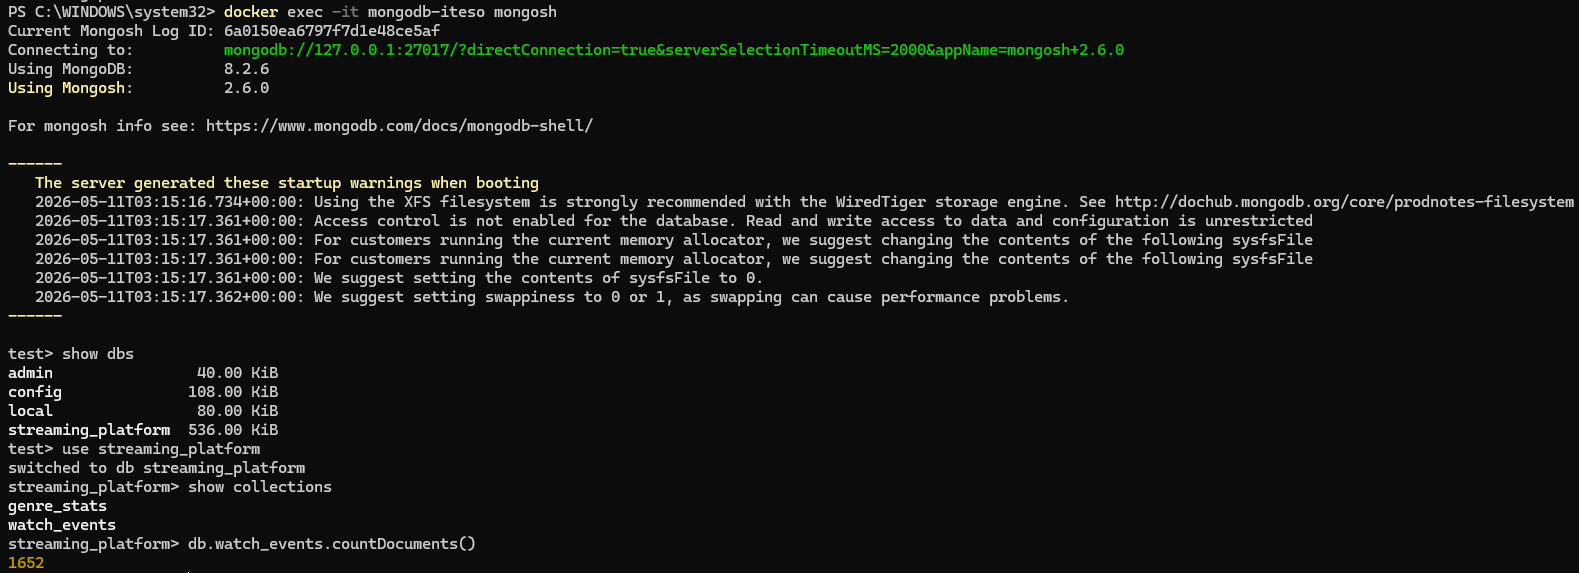

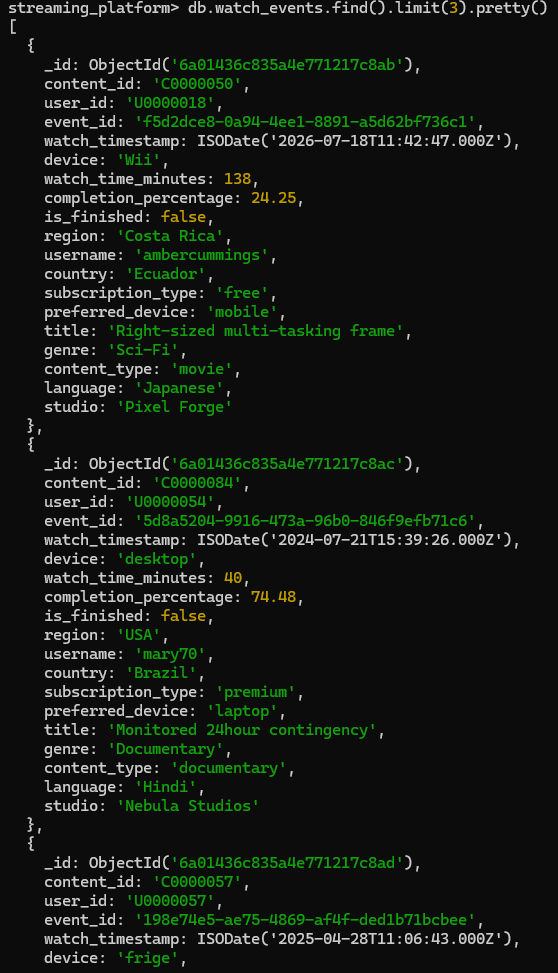

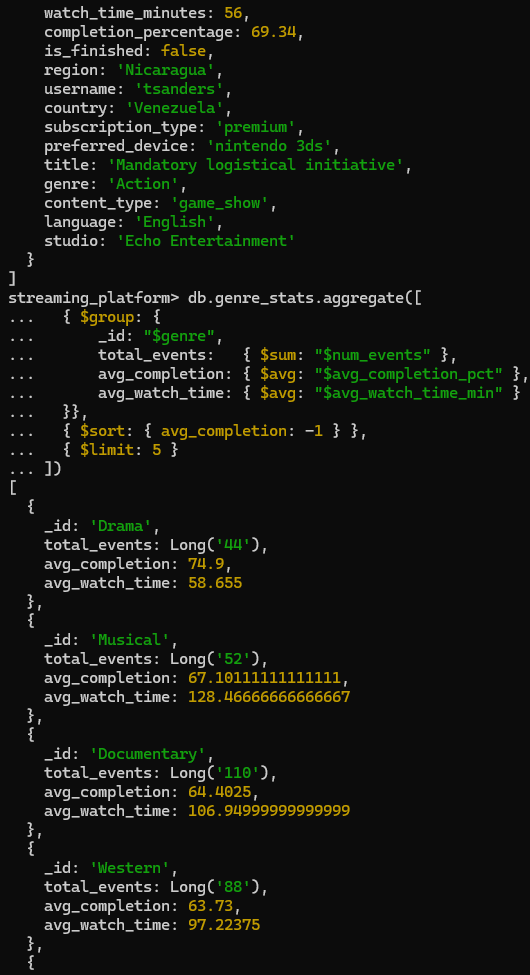

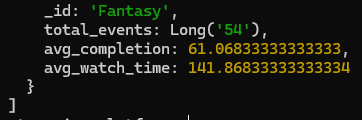

In [ ]:
su.spark.stop()